# 1 - Text Emotion Classification - Deep Learning

<img src='https://png.pngtree.com/png-vector/20231123/ourmid/pngtree-emotion-word-cloud-people-png-image_10685761.png'>

Bu çalışmada metinlerdeki duygu etiketlerini tahmin etmek için LSTM tabanlı bir deep learning modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Tokenization ve sequence hazırlama
6. LSTM modeli kurma
7. Tahmin
8. Sonuç


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


## 1. Veriyi Yükleme

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Sentiment Analysis Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config', 'drive', 'GoEmotions', 'DailyDialog.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [4]:
# Bu bölümde DailyDialog veri setini okuyup genel yapısını inceleyeceğim.

In [5]:
df = pd.read_csv('/content/DailyDialog.csv')
df.head()


,text,sentiment
0,I experienced this emotion when my grandfather...,sadness
1,"when I first moved in , I walked everywhere ....",neutral
2,"` Oh ! "" she bleated , her voice high and rath...",anger
3,"However , does the right hon. Gentleman recogn...",fear
4,My boyfriend didn't turn up after promising th...,sadness


In [6]:
df.shape


(11327, 2)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11327 entries, 0 to 11326
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       11327 non-null  object
 1   sentiment  11327 non-null  object
dtypes: object(2)
memory usage: 177.1+ KB


In [8]:
df['sentiment'].value_counts()


,count
sentiment,
joy,2326
sadness,2317
anger,2259
neutral,2254
fear,2171


## 3. Veri Temizleme

In [9]:
# Bu bölümde boş metinleri temizleyip metin sütununu string tipine dönüştüreceğim.

In [10]:
df = df.dropna(subset=['text', 'sentiment'])
df['text'] = df['text'].astype(str)
df.head()


,text,sentiment
0,I experienced this emotion when my grandfather...,sadness
1,"when I first moved in , I walked everywhere ....",neutral
2,"` Oh ! "" she bleated , her voice high and rath...",anger
3,"However , does the right hon. Gentleman recogn...",fear
4,My boyfriend didn't turn up after promising th...,sadness


## 4. Feature Engineering

In [11]:
# Bu bölümde duygu etiketlerini sayısal forma çevirip eğitim ve test verisini ayıracağım.

In [12]:
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

x_train, x_test, y_train, y_test = train_test_split(
    df['text'],
    df['sentiment_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment_encoded']
)

x_train.shape, x_test.shape


((9061,), (2266,))

## 5. Tokenization ve Sequence Hazırlama

In [13]:
# Bu bölümde metinleri tokenlara ayırıp LSTM için sabit uzunlukta sequence haline getireceğim.

In [14]:
max_words = 15000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

x_train_pad.shape, x_test_pad.shape


((9061, 150), (2266, 150))

## 6. LSTM Modeli Kurma

In [15]:
# Bu bölümde Embedding ve LSTM katmanlarını kullanarak deep learning modelini kurup eğiteceğim.

In [16]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=200, input_length=max_len))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train_pad, y_train_cat, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3667 - loss: 1.3860 - val_accuracy: 0.4804 - val_loss: 1.2106
Epoch 2/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6322 - loss: 0.9574 - val_accuracy: 0.6597 - val_loss: 0.9155
Epoch 3/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8110 - loss: 0.5654 - val_accuracy: 0.6917 - val_loss: 0.9027
Epoch 4/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8863 - loss: 0.3685 - val_accuracy: 0.6983 - val_loss: 0.9303
Epoch 5/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9211 - loss: 0.2602 - val_accuracy: 0.6900 - val_loss: 1.0123
Epoch 6/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9458 - loss: 0.1953 - val_accuracy: 0.6961 - val_loss: 1.1630


## 7. Tahmin

In [17]:
# Bu bölümde test verisi üzerinde tahmin yapıp accuracy ve F1 score ile değerlendireceğim.

In [18]:
y_pred_probs = model.predict(x_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print('Accuracy:', round(accuracy, 4))
print('F1 Score:', round(f1, 4))


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy: 0.6933
F1 Score: 0.6941


In [19]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

       anger       0.60      0.65      0.62       452
        fear       0.71      0.68      0.69       434
         joy       0.76      0.63      0.69       465
     neutral       0.80      0.79      0.79       451
     sadness       0.63      0.72      0.67       464

    accuracy                           0.69      2266
   macro avg       0.70      0.69      0.69      2266
weighted avg       0.70      0.69      0.69      2266



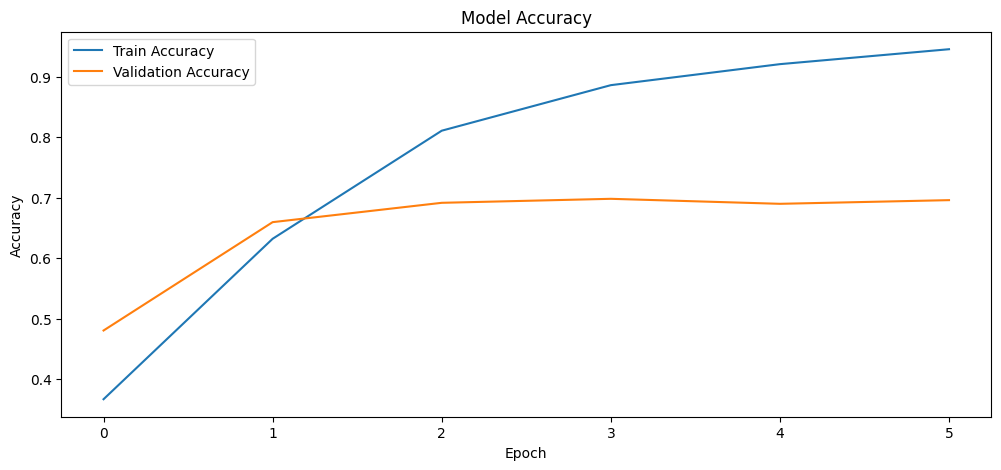

In [20]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 8. Sonuç

Bu projede metin duygu sınıflandırması için LSTM tabanlı bir deep learning modeli kullanıldı. Elde edilen sonuçlara göre model test verisi üzerinde duygu etiketlerini tahmin etti ve 0.6933 accuracy ile 0.6941 F1 score değeri elde etti.